In [1]:
# NAME: ANISA SACHDEV
# SECTION: G
#CMS-ID : 023-24-0222
# GITHUB LINK:


In [ ]:
import pandas as pd

df = pd.read_csv('clean_churn.csv')

print(df.head())

In [ ]:
df.shape

(7043, 20)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [ ]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [ ]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [ ]:
# This dataset is of telecom company that is interested in knowing on what basis the customers are switching/leaving company 
# for competitors. Based on this data we have to evaluate what are the key factors that are the basis for a customer churn.
# We are basically training our model based on this dataset that weather the remaining customer will churn or not so that appropriate 
# actions can be taken fastly and promptly.

In [ ]:
# part 2

In [ ]:
y = df['Churn'].map({'Yes':1,'No':0})
x = df.drop(columns=['Churn'])

print(x)
print(y)

      gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0     Female              0     Yes         No       1           No   
1       Male              0      No         No      34          Yes   
2       Male              0      No         No       2          Yes   
3       Male              0      No         No      45           No   
4     Female              0      No         No       2          Yes   
...      ...            ...     ...        ...     ...          ...   
7038    Male              0     Yes        Yes      24          Yes   
7039  Female              0     Yes        Yes      72          Yes   
7040  Female              0     Yes        Yes      11           No   
7041    Male              1     Yes         No       4          Yes   
7042    Male              0      No         No      66          Yes   

         MultipleLines InternetService OnlineSecurity OnlineBackup  \
0     No phone service             DSL             No          Yes   
1      

In [ ]:
categorical_col = x.select_dtypes(include='object').columns
x = pd.get_dummies(x,categorical_col,dtype=int)


In [ ]:
# for churn column i used manual mapping because it was only one column with binary values so it was relatively easy.
# on the other hand the other columns that were in x had many columns with object dtype. Therefore, in order to make my work easy 
# i used one hot encoding. 

In [ ]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 45 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   SeniorCitizen                            7043 non-null   int64  
 1   tenure                                   7043 non-null   int64  
 2   MonthlyCharges                           7043 non-null   float64
 3   TotalCharges                             7043 non-null   float64
 4   gender_Female                            7043 non-null   int64  
 5   gender_Male                              7043 non-null   int64  
 6   Partner_No                               7043 non-null   int64  
 7   Partner_Yes                              7043 non-null   int64  
 8   Dependents_No                            7043 non-null   int64  
 9   Dependents_Yes                           7043 non-null   int64  
 10  PhoneService_No                          7043 no

In [ ]:
# part 3

In [ ]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

# as we know from lab 2 that our dataset is class imbalance.
# Stratification ensures that both the training and test sets
# contain approximately the same proportion of churned and non-churned customers as the original dataset.

In [ ]:
print("X_train:", x_train.shape)
print("X_test:", x_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 45)
X_test: (1409, 45)
y_train: (5634,)
y_test: (1409,)


In [ ]:
# part 4

In [ ]:
model = DecisionTreeClassifier(random_state=42)
model.fit(x_train, y_train)
y_train_pred = model.predict(x_train)
y_test_pred = model.predict(x_test)

In [ ]:
model.get_depth()
#no it does not surprise me at all because we have not bounded the model with a max depth so it has a free hand to go as deep as he wants 

22

In [ ]:
# part 5

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

metrics = pd.DataFrame({
    'metric' : ['accuracy', 'precision', 'recall', 'f1'],
    'score' : [accuracy, precision, recall, f1]  
})

print(metrics)

      metric     score
0   accuracy  0.728886
1  precision  0.489637
2     recall  0.505348
3         f1  0.497368


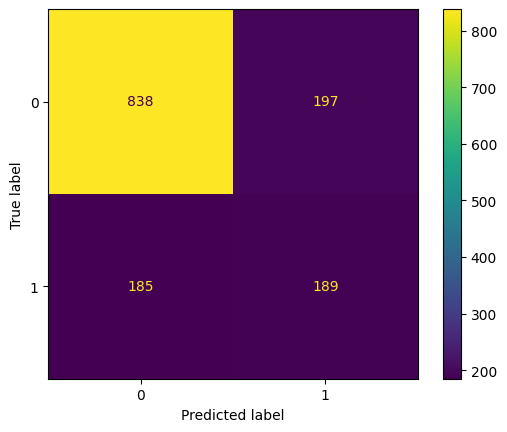

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_test_pred)
cm

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()


In [ ]:
# because the churn target is imbalance accuracy alone is not a good metric. I would prefer recall as it would tell us
# the actual churners.

In [ ]:
# part 6

In [ ]:
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("train accuracy", train_accuracy)
print("test accuracy", test_accuracy)

# the model performs well on training data but results are poor on the test data. This result suggests that the model is overfitting.


train accuracy 0.9980475683351083
test accuracy 0.7288857345635202


In [ ]:
depths = [2,3,4,5,6,8,10,None]
results = []

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(x_train, y_train)

    y_train_pred = tree.predict(x_train)
    y_test_pred = tree.predict(x_test)

    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    results.append({
        'max-depth' : depth,
        'train_accuracy' : train_accuracy,
        'test_accuracy' : test_accuracy
    })

results_df = pd.DataFrame(results)
results_df

,max-depth,train_accuracy,test_accuracy
0,2.0,0.765353,0.750887
1,3.0,0.791445,0.782115
2,4.0,0.796592,0.792051
3,5.0,0.803869,0.798439
4,6.0,0.810437,0.791341
5,8.0,0.837238,0.774308
6,10.0,0.878417,0.753726
7,NaN,0.998048,0.728886


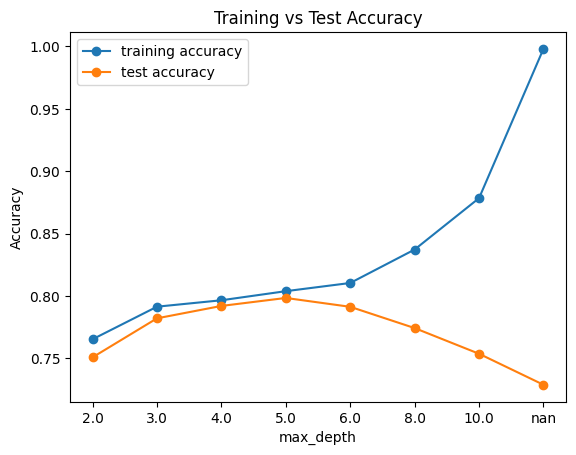

In [ ]:
import matplotlib.pyplot as plt

plt.plot(results_df['max-depth'].astype(str), results_df['train_accuracy'], marker='o', label='training accuracy')

plt.plot(results_df['max-depth'].astype(str), results_df['test_accuracy'], marker='o', label='test accuracy')

plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Training vs Test Accuracy')
plt.legend()
plt.show() 

# we can clearly see that after depth 5 a sudden distance is observed. This is where the model starts overfitting.

In [ ]:
# part 7

In [ ]:
# based on the above result max-depth 5 gives the best result because after that the model starts to overfit. At this very depth the model
# test result and train result have minimum differene.


In [ ]:
best_model = DecisionTreeClassifier(max_depth=5,random_state=42)

best_model.fit(x_train, y_train)

best_y_test_pred = best_model.predict(x_test)

accuracy = accuracy_score(y_test, best_y_test_pred)
precision = precision_score(y_test, best_y_test_pred)
recall = recall_score(y_test, best_y_test_pred)
f1 = f1_score(y_test, best_y_test_pred)

best_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Score': [accuracy, precision, recall, f1]
})

best_metrics

,Metric,Score
0,Accuracy,0.798439
1,Precision,0.634731
2,Recall,0.566845
3,F1-score,0.598870


In [ ]:
entropy_model = DecisionTreeClassifier(max_depth=5,criterion='entropy',random_state=42)

entropy_model.fit(x_train, y_train)

entropy_y_test_pred = entropy_model.predict(x_test)


entropy_accuracy = accuracy_score(y_test, entropy_y_test_pred)
entropy_precision = precision_score(y_test, entropy_y_test_pred)
entropy_recall = recall_score(y_test, entropy_y_test_pred)
entropy_f1 = f1_score(y_test, entropy_y_test_pred)

entropy_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Score': [
        entropy_accuracy,
        entropy_precision,
        entropy_recall,
        entropy_f1
    ]
})

entropy_metrics

,Metric,Score
0,Accuracy,0.797019
1,Precision,0.630952
2,Recall,0.566845
3,F1-score,0.597183


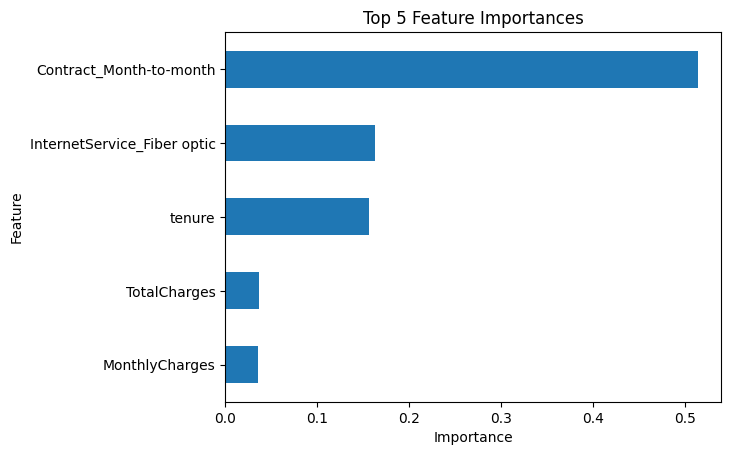

In [ ]:
importances = best_model.feature_importances_

feature_importance = pd.Series(importances, index=x_train.columns).sort_values(ascending=False)
top_5 = feature_importance.head(5)
top_5

top_5.sort_values().plot(kind='barh')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 5 Feature Importances')
plt.show()

# the top five features that matter the most are shown in the graph.

In [ ]:
# yes totally the pattern is matching.
# In lab 2 we show that the churn ratio for month to month customers was much higher than others and we can exactly see here that 
# that thing is proving itself.

In [ ]:
# part 8

In [ ]:
# I landed on model with dept=5. It performed well out of all other models with different depths. At depth 5 the model gave the best 
# possible prediction that it can give. The main limitations are that the accuracy is around 80 percent which means 20 percent customers
# are still being predicted wrong.

In [ ]:
# if i had more time i would probably go for feature extraction part. I will evaluate the features more closely and try to use those 
# features that would result in better predicting ratio.

In [ ]:
import pandas as pd
import math 

data = {
    'Outlook':['Sunny', 'Sunny', 'Overcast', 'Rainy','Rainy', 'Rainy', 'Overcast', 'Sunny','Sunny', 'Rainy', 'Sunny', 'Overcast','Overcast', 'Rainy'],
     'Temp': ['Hot', 'Hot', 'Hot', 'Mild','Cool', 'Cool', 'Cool', 'Mild','Cool', 'Mild', 'Mild', 'Mild','Hot', 'Mild'],
    'Humidity': ['High', 'High', 'High', 'High','Normal', 'Normal', 'Normal', 'High','Normal', 'Normal', 'Normal', 'High','Normal', 'High'],
    'Windy': ['Weak', 'Strong', 'Weak', 'Weak','Weak', 'Strong', 'Strong', 'Weak','Weak', 'Weak', 'Strong', 'Strong','Weak', 'Strong'],
    'Play': ['No', 'No', 'Yes', 'Yes','Yes', 'No', 'Yes', 'No','Yes', 'Yes', 'Yes', 'Yes','Yes', 'No']
}

df = pd.DataFrame(data)
df

def entropy(data, target='Play'):
    counts = data[target].value_counts()
    total = len(data)
    entropy_value = 0

    for count in counts:
        probability = count/total
        entropy_value -= probability * math.log2(probability)
    return entropy_value

print(entropy(df))

def information_gain(data, attribute, target='Play'):
    total_entropy = entropy(data,target)
    values = data[attribute].unique()
    weighted_entropy = 0

    for value in values:
        subset = data[data[attribute] == value]
        weight = len(subset) / len(data)
        subset_entropy = entropy(subset,target)
        weighted_entropy += weight*subset_entropy

    gain = total_entropy - weighted_entropy

    return gain

attributes = ['Outlook','Temp','Humidity','Windy']

for attribute in attributes:
    gain = information_gain(df, attribute)
    print(attribute, ':', gain)

def majority_class(data, target='Play'):
    return data[target].value_counts().idmax()
    

def id3(data, attributes, target='Play', depth=0):

    classes = data[target].unique()

    if len(classes) == 1:

        return classes[0]

    if len(attributes) == 0:

        return majority_class(data, target)

    gains = {}

    print("\n" + "  " * depth + "Current split:")
    print("  " * depth + f"Samples: {len(data)}")

    for attribute in attributes:

        gain = information_gain(data, attribute, target)

        gains[attribute] = gain

        print("  " * depth + f"Gain({attribute}) = {gain:.4f}")

    best_attribute = max(gains, key=gains.get)

    print("  " * depth + f"Best attribute: {best_attribute}")

    tree = {best_attribute: {}}

    remaining_attributes = [
        attribute
        for attribute in attributes
        if attribute != best_attribute
    ]

    for value in data[best_attribute].unique():

        subset = data[
            data[best_attribute] == value
        ].drop(columns=[best_attribute])

        print("\n" + "  " * depth + f"{best_attribute} = {value}")

        if len(subset) == 0:

            tree[best_attribute][value] = majority_class(data, target)

        else:

            tree[best_attribute][value] = id3(
                subset,
                remaining_attributes,
                target,
                depth + 1
            )

    return tree

attributes = ['Outlook', 'Temp', 'Humidity', 'Windy']
tree = id3(df, attributes)
print("Final Decision Tree:")
print(tree)

0.9402859586706311
Outlook : 0.24674981977443933
Temp : 0.02922256565895487
Humidity : 0.15183550136234159
Windy : 0.04812703040826949

Current split:
Samples: 14
Gain(Outlook) = 0.2467
Gain(Temp) = 0.0292
Gain(Humidity) = 0.1518
Gain(Windy) = 0.0481
Best attribute: Outlook

Outlook = Sunny

  Current split:
  Samples: 5
  Gain(Temp) = 0.5710
  Gain(Humidity) = 0.9710
  Gain(Windy) = 0.0200
  Best attribute: Humidity

  Humidity = High

  Humidity = Normal

Outlook = Overcast

Outlook = Rainy

  Current split:
  Samples: 5
  Gain(Temp) = 0.0200
  Gain(Humidity) = 0.0200
  Gain(Windy) = 0.9710
  Best attribute: Windy

  Windy = Weak

  Windy = Strong
Final Decision Tree:
{'Outlook': {'Sunny': {'Humidity': {'High': 'No', 'Normal': 'Yes'}}, 'Overcast': 'Yes', 'Rainy': {'Windy': {'Weak': 'Yes', 'Strong': 'No'}}}}
